<a href="https://colab.research.google.com/github/QangDuc/deeplearning/blob/main/TH_DLN_Tuan3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#CNN

Bai 1

Import thư viện

In [5]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

Load dữ liệu CIFAR10

In [6]:
# Load dataset CIFAR10
(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()

# Kiểm tra kích thước dữ liệu
print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


Chuẩn hóa dữ liệu

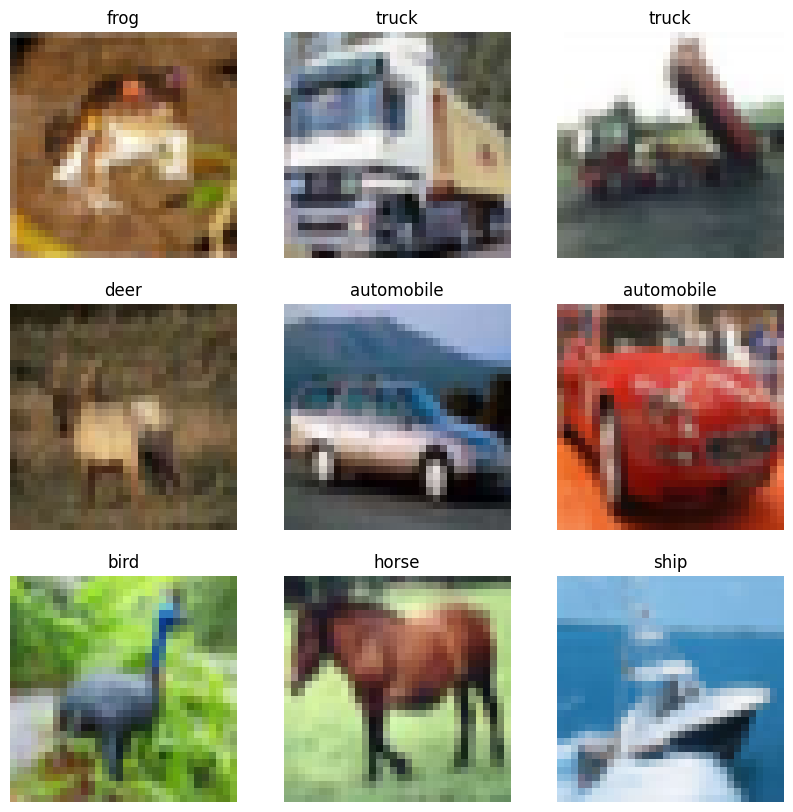

In [7]:
x_train = x_train / 255.0
x_test = x_test / 255.0

class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')

plt.show()

Xây dựng mô hình CNN

In [8]:
model = models.Sequential()

# Convolution layer 1
model.add(layers.Conv2D(32, (3,3), activation='relu',
                        input_shape=(32,32,3)))
model.add(layers.MaxPooling2D((2,2)))

# Convolution layer 2
model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

# Convolution layer 3
model.add(layers.Conv2D(64, (3,3), activation='relu'))

# Flatten
model.add(layers.Flatten())

# Fully connected
model.add(layers.Dense(64, activation='relu'))

# Output layer
model.add(layers.Dense(10, activation='softmax'))

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Huấn luyện mô hình

In [9]:
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    validation_data=(x_test, y_test)
)

test_loss, test_acc = model.evaluate(x_test, y_test)

print("Test accuracy:", test_acc)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 78s 49ms/step - accuracy: 0.4436 - loss: 1.5278 - val_accuracy: 0.5422 - val_loss: 1.2627
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 78s 47ms/step - accuracy: 0.5806 - loss: 1.1697 - val_accuracy: 0.6149 - val_loss: 1.0830
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 84s 48ms/step - accuracy: 0.6370 - loss: 1.0277 - val_accuracy: 0.6514 - val_loss: 0.9909
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 47ms/step - accuracy: 0.6727 - loss: 0.9316 - val_accuracy: 0.6600 - val_loss: 0.9921
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 74s 48ms/step - accuracy: 0.6955 - loss: 0.8632 - val_accuracy: 0.6870 - val_loss: 0.9043
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 80s 46ms/step - accuracy: 0.7152 - loss: 0.8090 - val_accuracy: 0.6942 - val_loss: 0.8993
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 73s 47ms/step - accuracy: 0.7315 - loss: 0.7628 - val_accuracy: 0.7005 - val_loss: 0.8748
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 74s 47ms/step - accuracy: 0.7480 -

Dự đoán ảnh mới

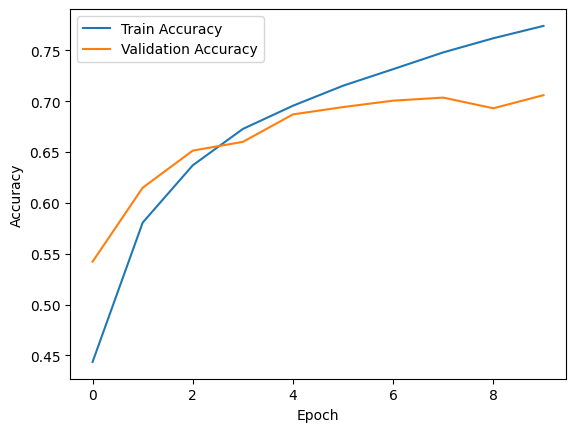

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step
Epoch 1
Train Accuracy     : 0.4436
Validation Accuracy: 0.5422
-----------------------------
Epoch 2
Train Accuracy     : 0.5806
Validation Accuracy: 0.6149
-----------------------------
Epoch 3
Train Accuracy     : 0.6370
Validation Accuracy: 0.6514
-----------------------------
Epoch 4
Train Accuracy     : 0.6727
Validation Accuracy: 0.6600
-----------------------------
Epoch 5
Train Accuracy     : 0.6955
Validation Accuracy: 0.6870
-----------------------------
Epoch 6
Train Accuracy     : 0.7152
Validation Accuracy: 0.6942
-----------------------------
Epoch 7
Train Accuracy     : 0.7315
Validation Accuracy: 0.7005
-----------------------------
Epoch 8
Train Accuracy     : 0.7480
Validation Accuracy: 0.7035
-----------------------------
Epoch 9
Train Accuracy     : 0.7619
Validation Accuracy: 0.6930
-----------------------------
Epoch 10
Train Accuracy     : 0.7740
Validation Accuracy: 0.7059
-----------------------------


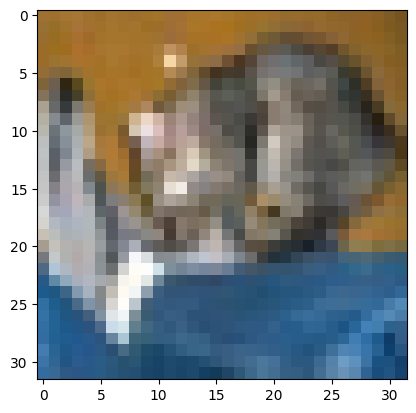

Predicted: cat
Actual: cat


In [12]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

predictions = model.predict(x_test)

train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

for i in range(len(train_acc)):
    print(f"Epoch {i+1}")
    print(f"Train Accuracy     : {train_acc[i]:.4f}")
    print(f"Validation Accuracy: {val_acc[i]:.4f}")
    print("-----------------------------")

# Lấy ảnh đầu tiên
index = 0

plt.imshow(x_test[index])
plt.show()

predicted_label = np.argmax(predictions[index])

print("Predicted:", class_names[predicted_label])
print("Actual:", class_names[y_test[index][0]])

model.save("cnn_cifar10.keras")

bai 2

Load dữ liệu

In [13]:
from tensorflow.keras.datasets import fashion_mnist

# Load dataset
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train shape: (60000, 28, 28)
Test shape: (10000, 28, 28)


Chương trình CNN

Train shape: (60000, 28, 28)
Test shape : (10000, 28, 28)


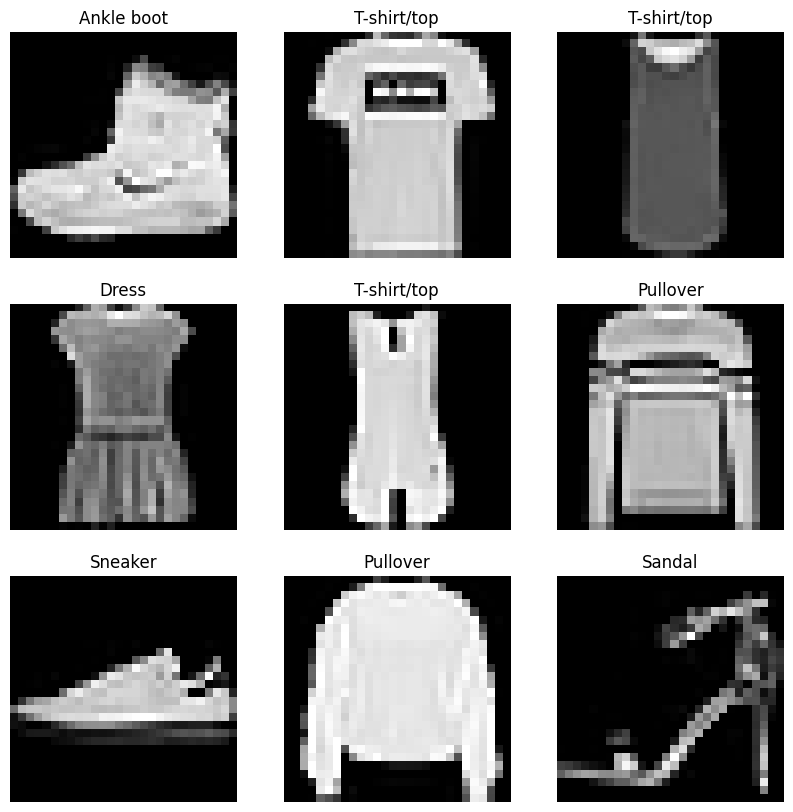

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 67s 34ms/step - accuracy: 0.8298 - loss: 0.4707 - val_accuracy: 0.8625 - val_loss: 0.3814
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 79s 33ms/step - accuracy: 0.8853 - loss: 0.3158 - val_accuracy: 0.8885 - val_loss: 0.3080
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 62s 33ms/step - accuracy: 0.9016 - loss: 0.2703 - val_accuracy: 0.8859 - val_loss: 0.3021
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 61s 32ms/step - accuracy: 0.9119 - loss: 0.2405 - val_accuracy: 0.8989 - val_loss: 0.2743
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 62s 33ms/step - accuracy: 0.9194 - loss: 0.2175 - val_accuracy: 0.9061 - val_loss: 0.2595
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 84s 34ms/step - accuracy: 0.9271 - loss: 0.1960 - val_accuracy: 0.9057 - val_loss: 0.2629
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 60s 32ms/step - accuracy: 0.9335 - loss: 0.1785 - val_accuracy: 0.9068 - val_loss: 0.2683
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 62s 33ms/step - accuracy: 0.9398 -

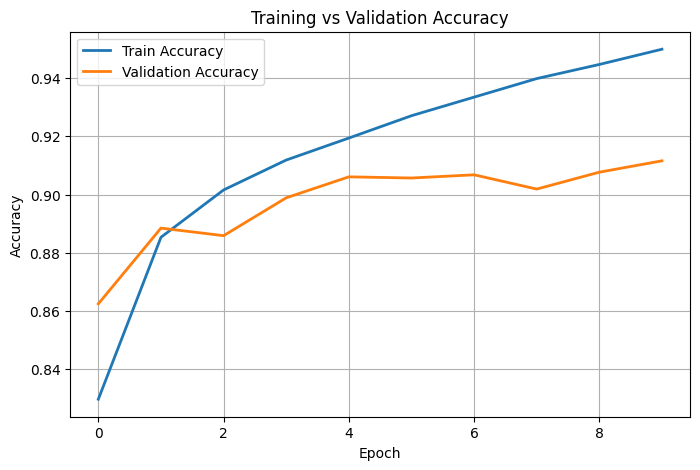

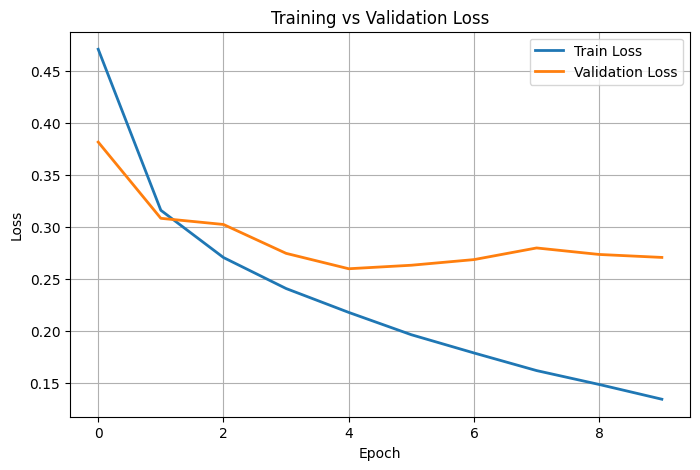

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step


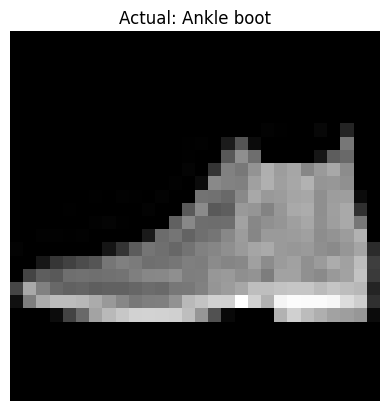

Predicted: Ankle boot
Actual   : Ankle boot


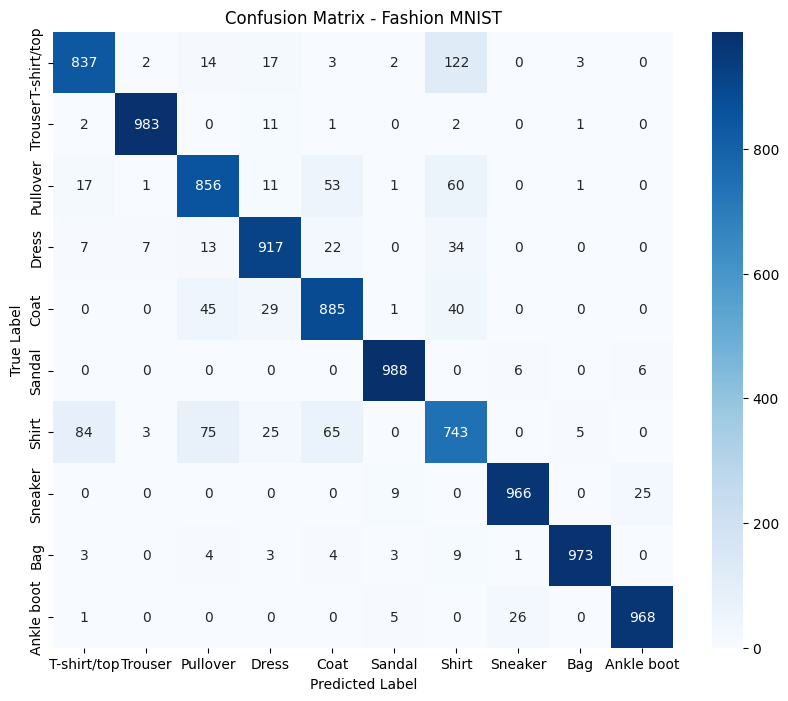


Model saved successfully!


In [15]:
# ==============================
# CNN Fashion-MNIST Classification
# ==============================

# Import thư viện
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from sklearn.metrics import confusion_matrix

# ==============================
# 1. Load dataset Fashion-MNIST
# ==============================

fashion_mnist = tf.keras.datasets.fashion_mnist

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

print("Train shape:", x_train.shape)
print("Test shape :", x_test.shape)

# ==============================
# 2. Normalize dữ liệu
# ==============================

x_train = x_train / 255.0
x_test = x_test / 255.0

# Reshape cho CNN
x_train = x_train.reshape((60000, 28, 28, 1))
x_test = x_test.reshape((10000, 28, 28, 1))

# ==============================
# 3. Tên các lớp
# ==============================

class_names = [
    'T-shirt/top',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle boot'
]

# ==============================
# 4. Hiển thị ảnh mẫu
# ==============================

plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[i].reshape(28,28), cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')

plt.show()

# ==============================
# 5. Xây dựng mô hình CNN
# ==============================

model = models.Sequential()

# Layer 1
model.add(layers.Conv2D(
    32,
    (3,3),
    activation='relu',
    input_shape=(28,28,1)
))

model.add(layers.MaxPooling2D((2,2)))

# Layer 2
model.add(layers.Conv2D(
    64,
    (3,3),
    activation='relu'
))

model.add(layers.MaxPooling2D((2,2)))

# Flatten
model.add(layers.Flatten())

# Fully Connected
model.add(layers.Dense(64, activation='relu'))

# Output layer
model.add(layers.Dense(10, activation='softmax'))

# ==============================
# 6. Compile mô hình
# ==============================

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# ==============================
# 7. Hiển thị cấu trúc model
# ==============================

model.summary()

# ==============================
# 8. Train mô hình
# ==============================

history = model.fit(
    x_train,
    y_train,
    epochs=10,
    validation_data=(x_test, y_test)
)

# ==============================
# 9. Đánh giá mô hình
# ==============================

test_loss, test_acc = model.evaluate(x_test, y_test)

print("\nTest Accuracy:", test_acc)

# ==============================
# 10. Hiển thị Accuracy
# ==============================

train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

for i in range(len(train_acc)):
    print(f"\nEpoch {i+1}")
    print(f"Train Accuracy     : {train_acc[i]:.4f}")
    print(f"Validation Accuracy: {val_acc[i]:.4f}")

# ==============================
# 11. Vẽ biểu đồ Accuracy
# ==============================

plt.figure(figsize=(8,5))

plt.plot(
    history.history['accuracy'],
    label='Train Accuracy',
    linewidth=2
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy',
    linewidth=2
)

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')

plt.legend()
plt.grid(True)

plt.show()

# ==============================
# 12. Vẽ biểu đồ Loss
# ==============================

plt.figure(figsize=(8,5))

plt.plot(
    history.history['loss'],
    label='Train Loss',
    linewidth=2
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss',
    linewidth=2
)

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')

plt.legend()
plt.grid(True)

plt.show()

# ==============================
# 13. Predict dữ liệu test
# ==============================

predictions = model.predict(x_test)

# Chuyển xác suất -> label
y_pred = np.argmax(predictions, axis=1)

# ==============================
# 14. Hiển thị dự đoán ảnh
# ==============================

index = 0

plt.imshow(
    x_test[index].reshape(28,28),
    cmap='gray'
)

plt.title("Actual: " + class_names[y_test[index]])

plt.axis('off')
plt.show()

print("Predicted:", class_names[y_pred[index]])
print("Actual   :", class_names[y_test[index]])

# ==============================
# 15. Confusion Matrix
# ==============================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Fashion MNIST")

plt.show()

# ==============================
# 16. Lưu model
# ==============================

model.save("fashion_mnist_cnn.keras")

print("\nModel saved successfully!")